# Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import adi

# Plotting Functions

In [2]:
def plot_scatter(signal):
    plt.figure(figsize=(3, 3))
    plt.scatter(signal.real, signal.imag, color='blue', alpha=0.5, s=20)
    plt.xlabel("Real Part")
    plt.ylabel("Imaginary Part")
    plt.grid(True)
    plt.axis('equal')
    plt.show()

def plot_signal(signal, length, label_name):
    plt.figure(figsize=(15, 3))
    plt.plot(signal[:length], '.-', label = label_name)
    # plt.grid(True)
    plt.legend()
    plt.show()

def smooth_psd_fft(rx_signal, fs, nperseg=1024):
    N = len(rx_signal)
    step = nperseg // 2  # 50% overlap
    psd_avg = np.zeros(nperseg)
    count = 0
    for i in range(0, N - nperseg, step):
        segment = rx_signal[i:i+nperseg]
        spectrum = np.fft.fftshift(np.fft.fft(segment, nperseg))
        psd = np.abs(spectrum)**2 / nperseg
        psd_avg += psd
        count += 1
    psd_avg /= count
    freq = np.fft.fftshift(np.fft.fftfreq(nperseg, 1/fs))
    freq, psd_smooth =  freq, psd_avg
    plt.figure(figsize=(4, 3))
    plt.plot(freq/1e6, 10*np.log10(psd_smooth))
    plt.title("Smoothed PSD (FFT averaging)")
    plt.xlabel("Frequency (MHz)")
    plt.ylabel("Power (dB)")
    plt.grid(True)
    plt.show()


# Configure SDR and Receive

In [3]:
sample_rate = 10e6 # Hz
carrier_freq = 985e6 # Hz
num_samps = 100000 

sdr2 = adi.Pluto("ip:192.168.3.1")
sdr2.sample_rate = int(sample_rate)

sdr2.rx_lo = int(carrier_freq)
sdr2.rx_rf_bandwidth = int(sample_rate)
sdr2.rx_buffer_size = num_samps
sdr2.gain_control_mode_chan0 = 'slow_attack'
# sdr2.rx_hardwaregain_chan0 = 70 # dB

rx_samples = sdr2.rx()
print('number of received signal samples:', len(rx_samples))

number of received signal samples: 100000


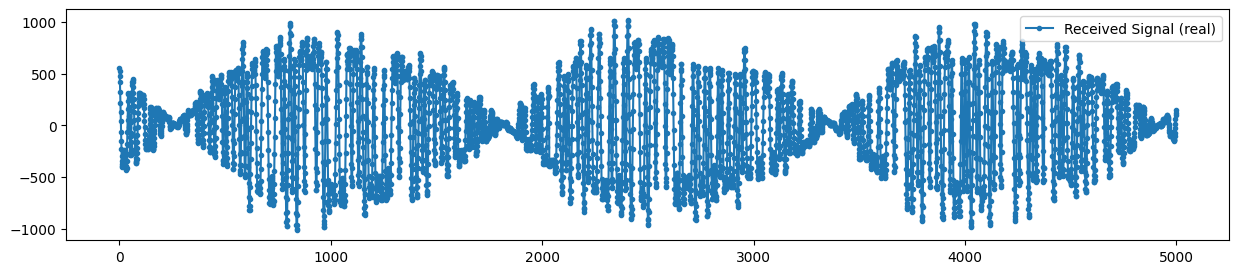

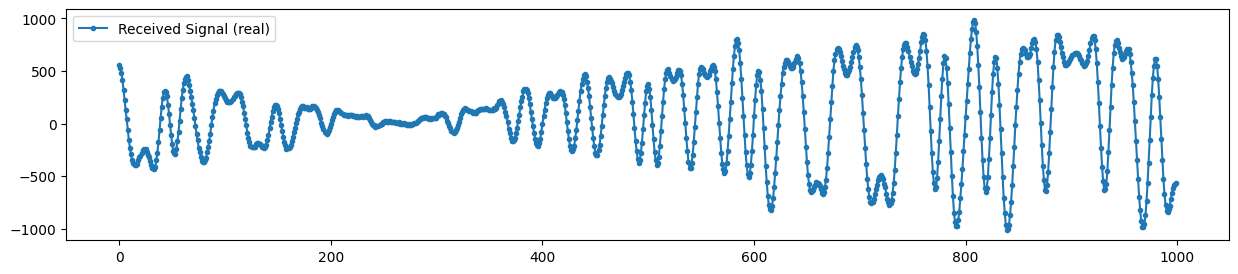

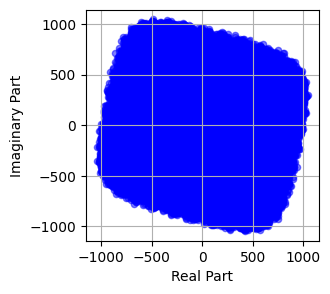

In [4]:
plot_signal(rx_samples.real, 5000, 'Received Signal (real)')  # Plotting first 5000 samples
plot_signal(rx_samples.real, 1000, 'Received Signal (real)') # Plotting first 1000 samples
plot_scatter(rx_samples)

### Plot Spectrum

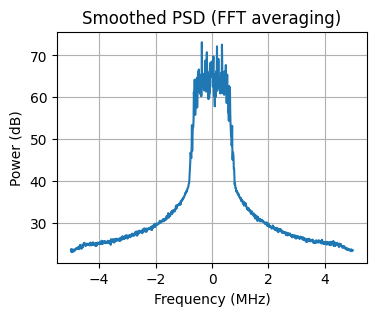

In [5]:
smooth_psd_fft(rx_samples, sample_rate)

# Matched Filtering

In [6]:
sps = 8
num_taps = 101
beta = 0.34
Ts = sps 
t = np.arange(num_taps) - (num_taps-1)//2
rc_pulse = np.sinc(t/Ts) * np.cos(np.pi*beta*t/Ts) / (1 - (2*beta*t/Ts)**2)
matched_filter =  rc_pulse
################################################################################
MF_op = np.convolve(rx_samples, matched_filter, mode='same')

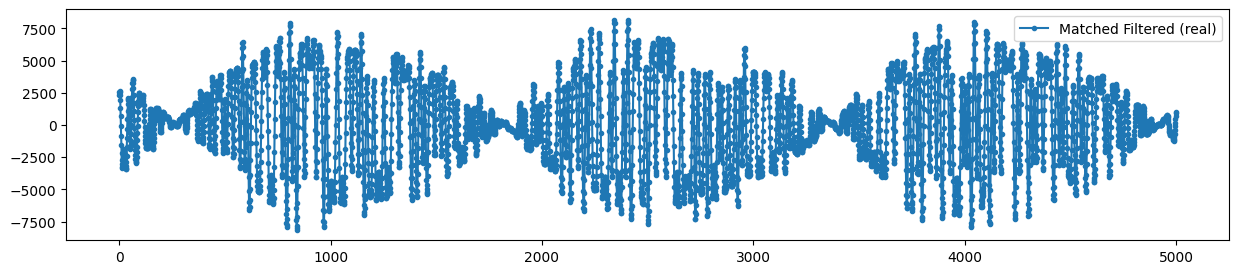

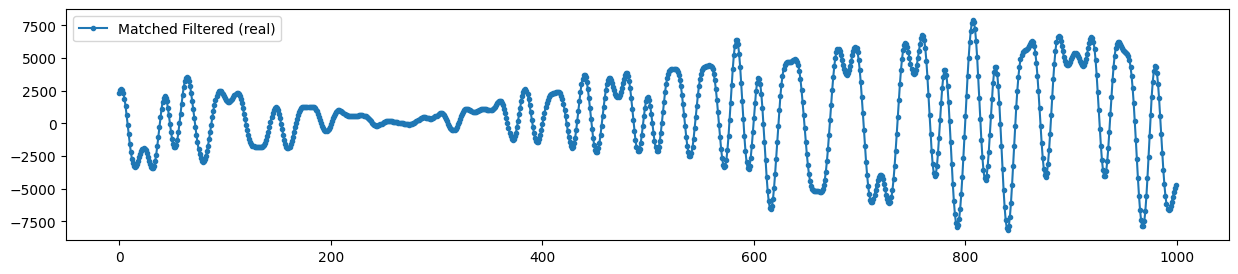

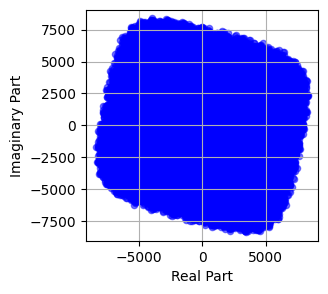

In [7]:
plot_signal(MF_op.real, 5000, 'Matched Filtered (real)') # Plotting first 5000 samples
plot_signal(MF_op.real, 1000, 'Matched Filtered (real)')# Plotting first 1000 samples
plot_scatter(MF_op)

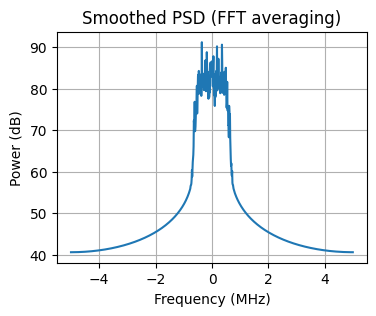

In [8]:
smooth_psd_fft(MF_op, sample_rate)

# Normalization 1

In [9]:
#updated code for normalization
max_allowed = 1.5
rx_max = np.max(np.abs(MF_op))
scale_coarse = max_allowed / rx_max
normalized_rx = MF_op * scale_coarse



# #old code
# magnitudes = np.abs(MF_op)
# normalized_rx = MF_op / magnitudes

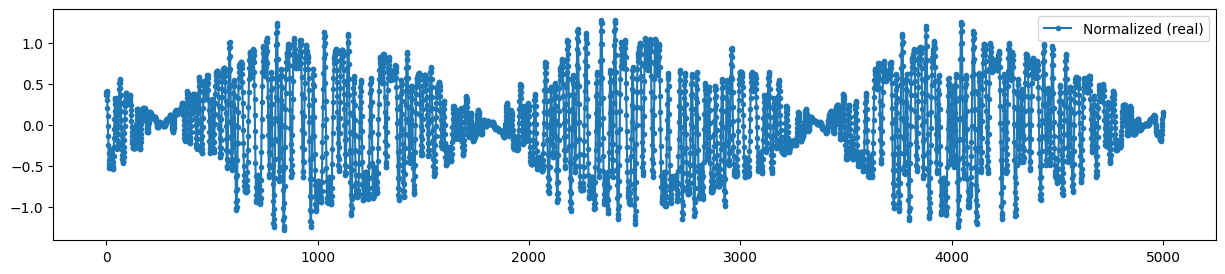

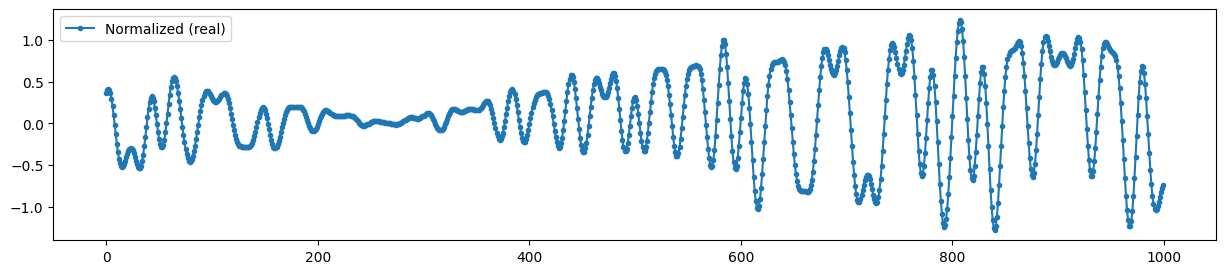

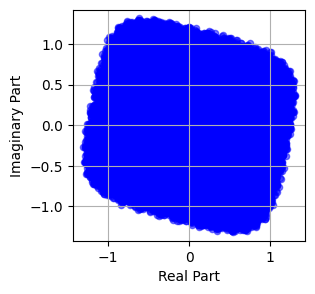

In [10]:
plot_signal(normalized_rx.real, 5000, 'Normalized (real)')  # Plotting first 5000 samples
plot_signal(normalized_rx.real, 1000, 'Normalized (real)') # Plotting first 1000 samples
plot_scatter(normalized_rx)

# Coarse Frequency Synchronization

### FFT based Offset Estimation

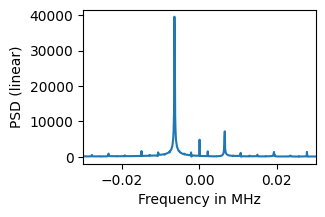

offset (Hz): -6450.06


In [11]:
squared_FO = normalized_rx**2

fs = sample_rate
psd = np.fft.fftshift(np.abs(np.fft.fft(squared_FO)))
f = np.linspace(-fs/2.0, fs/2.0, len(psd))
######################################################
plt.figure(figsize=(3, 2))
plt.plot(f/1e6, psd)
plt.xlabel('Frequency in MHz')
plt.ylabel('PSD (linear)')
plt.xlim(-0.03, 0.03)
plt.show()
############################################################

max_freq = f[np.argmax(psd)]
print('offset (Hz):', np.round(max_freq, 2))

### Coarse Frequency Correction

In [12]:
Ts = 1/fs
t = np.arange(0, Ts*len(normalized_rx), Ts) # create time vector
coarse_corrected = normalized_rx * np.exp(-1j*2*np.pi*max_freq*t/2.0)

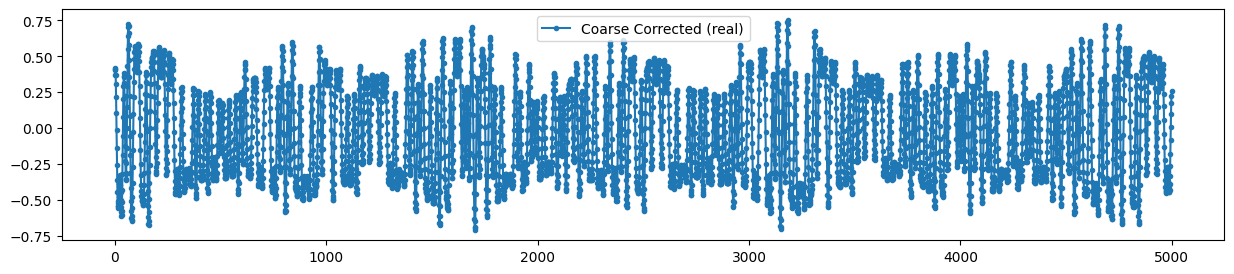

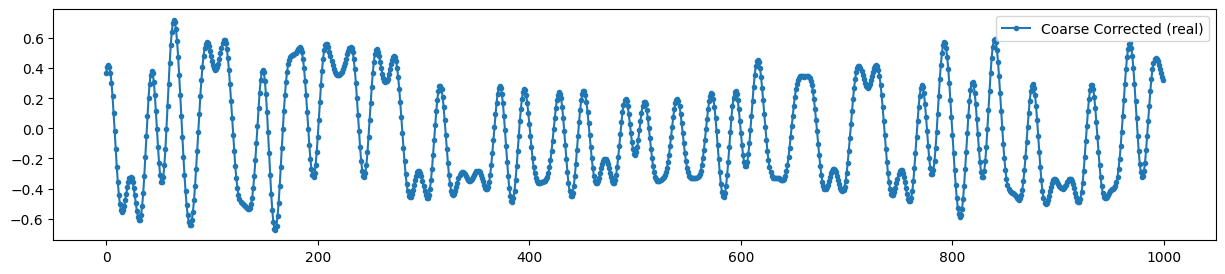

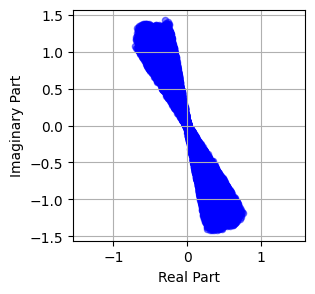

In [13]:
plot_signal(coarse_corrected.real, 5000, 'Coarse Corrected (real)') # Plotting first 5000 samples
plot_signal(coarse_corrected.real, 1000, 'Coarse Corrected (real)')# Plotting first 1000 samples
plot_scatter(coarse_corrected)

## Normalization 2 (Increase Signal Amplitude)
### Unit Power Normalization 

In [14]:
# Unit power normalization
power = np.mean(np.abs(coarse_corrected)**2)
normalized_2 = coarse_corrected / np.sqrt(power)

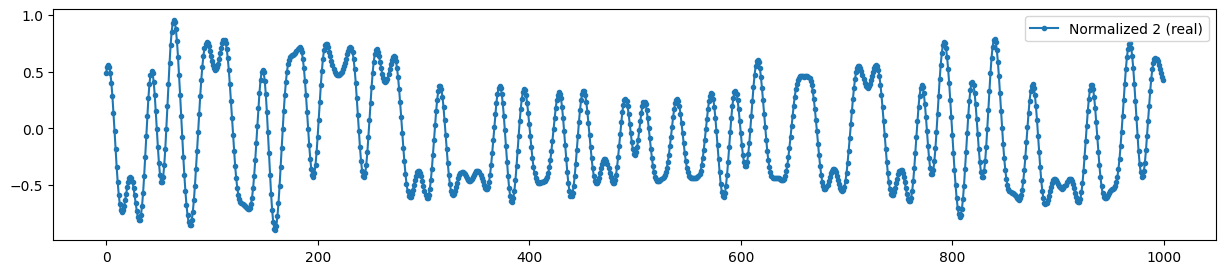

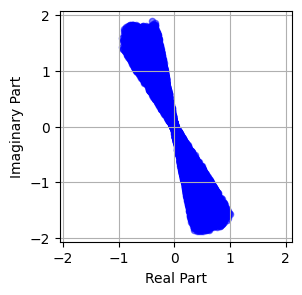

In [15]:
plot_signal(normalized_2.real, 1000, 'Normalized 2 (real)')
plot_scatter(normalized_2)

# Fine Frequency Synchronization

### Costas Loop

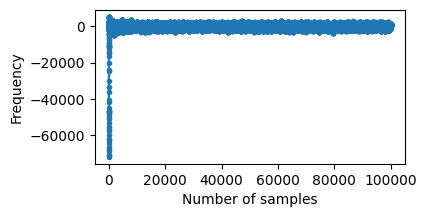

In [16]:
samples = normalized_2
N = len(samples)
phase = 0
freq = 0
alpha = 0.132
beta = 0.00932
fine_correct = np.zeros(N, dtype=np.complex64)
freq_log = []
for i in range(N):
    fine_correct[i] = samples[i] * np.exp(-1j*phase)
    error = np.real(fine_correct[i]) * np.imag(fine_correct[i]) 
    freq += (beta * error)
    freq_log.append(freq * fs / (2*np.pi)) 
    phase += freq + (alpha * error)
    while phase >= 2*np.pi:
        phase -= 2*np.pi
    while phase < 0:
        phase += 2*np.pi

plt.figure(figsize=(4, 2))
plt.plot(freq_log,'.-')
plt.xlabel('Number of samples')
plt.ylabel('Frequency')
# plt.ylim(0, 10000)
plt.show()

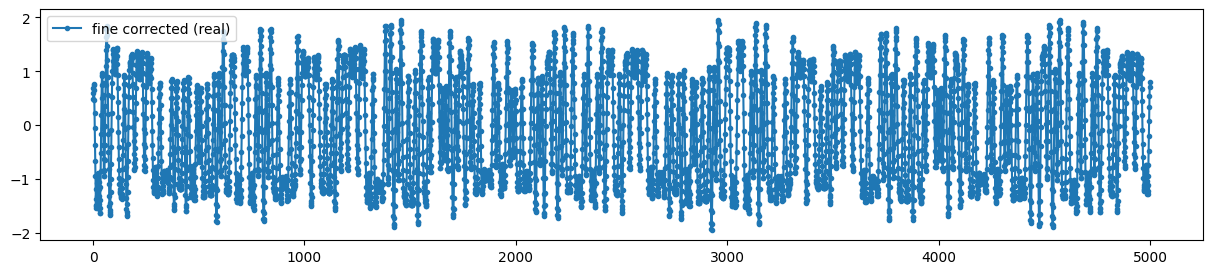

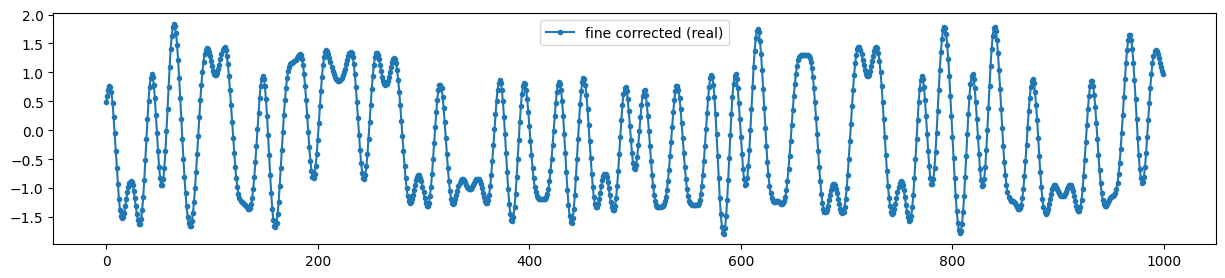

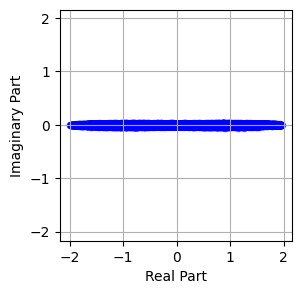

In [17]:
plot_signal(fine_correct.real, 5000, 'fine corrected (real)') # Plotting first 5000 samples
plot_signal(fine_correct.real, 1000, 'fine corrected (real)') # Plotting first 1000 samples
plot_scatter(fine_correct[100:])

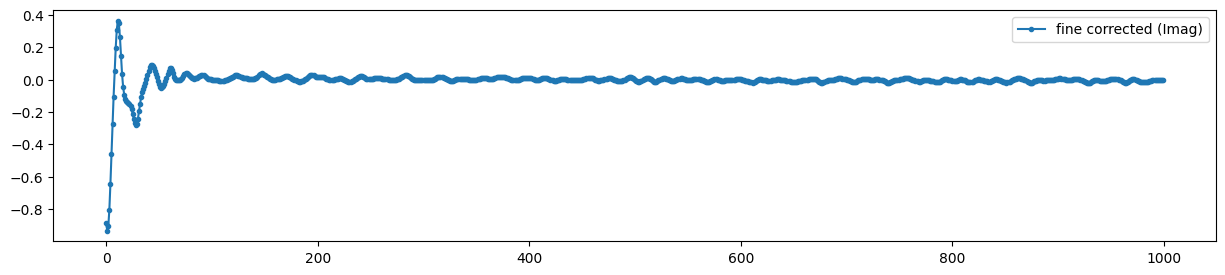

In [18]:
#plotting imaginary signal - To check complete offset removed or not
plot_signal(fine_correct.imag, 1000, 'fine corrected (Imag)') # Plotting first 1000 samples

# Time Synchronization

### Basic - Larger sps (16) + Downsampling

In [19]:
# downsampling_factor = sps
# down_sampled = fine_correct[::downsampling_factor]

# time_sync = down_sampled

### Improvement
### Mueller and Muller clock recovery technique

In [20]:
samples  = fine_correct[100:]
samples_interpolated = signal.resample_poly(samples, 16, 1)
mu = 0 
out = np.zeros(len(samples) + 10, dtype=np.complex64)
out_rail = np.zeros(len(samples) + 10, dtype=np.complex64) #
i_in = 0 
i_out = 2 
while i_out < len(samples) and i_in+16 < len(samples):
    out[i_out] = samples_interpolated[i_in*16 + int(mu*16)]
    out_rail[i_out] = int(np.real(out[i_out]) > 0) + 1j*int(np.imag(out[i_out]) > 0)
    x = (out_rail[i_out] - out_rail[i_out-2]) * np.conj(out[i_out-1])
    y = (out[i_out] - out[i_out-2]) * np.conj(out_rail[i_out-1])
    mm_val = np.real(y - x)
    mu += sps + 0.3*mm_val
    i_in += int(np.floor(mu))
    mu = mu - np.floor(mu) 
    i_out += 1 
out = out[2:i_out] 
time_sync = out

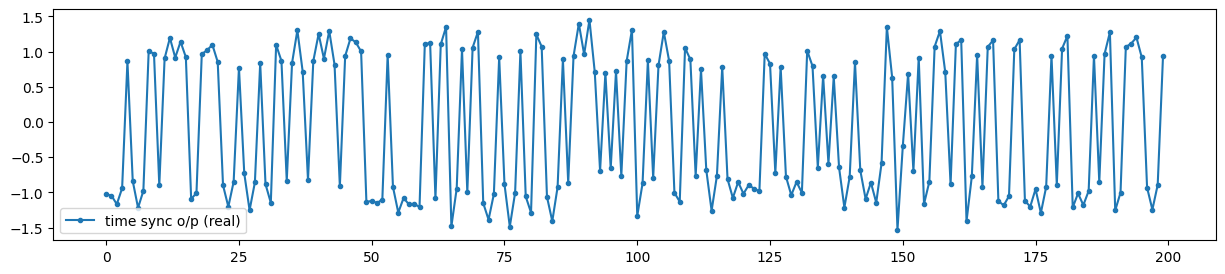

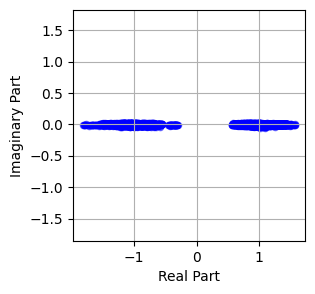

In [21]:
plot_signal(time_sync[100:].real, 200, 'time sync o/p (real)')
plot_scatter(time_sync[100:])

# Frame Synchronization - Barker

peak: -13.717


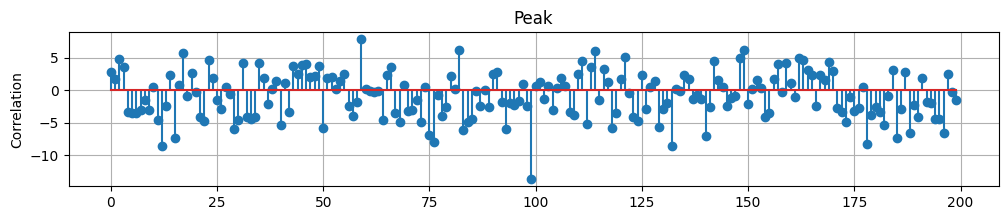

In [22]:
barker_code = np.array([1, 1, 1, 1, 1, -1, -1, 1, 1, -1, 1, -1, 1])
barker_correlated = np.correlate(time_sync, barker_code, mode='full')
offset  = np.argmax(np.abs(barker_correlated))+1

peak = np.real(barker_correlated)[offset-1]
print('peak:', np.round(peak, 3))
if peak < 0:
    time_sync = -1*time_sync

#######################################################
plt.figure(figsize=(12, 2))
plt.stem(barker_correlated.real[offset-100:offset+100])
plt.title('Peak')
plt.ylabel('Correlation')
plt.grid(True)
plt.show()

In [23]:
# Collect samples after offset 
n_bits = 280  # Number of message bits
fr_sync_op = time_sync[offset:offset+n_bits]

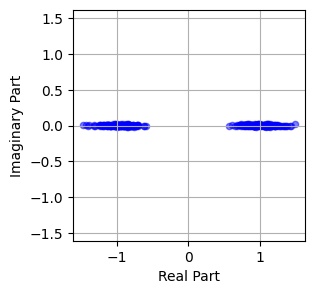

In [24]:
plot_scatter(fr_sync_op)

# BPSK Demodulation

In [25]:
recovered_bits = (fr_sync_op > 0).astype(int)
print('recovered_bits\n', recovered_bits)

recovered_bits
 [1 0 0 0 1 0 0 1 1 0 1 0 0 1 1 1 0 0 1 1 1 1 1 0 1 0 0 1 1 1 1 0 1 0 0 1 1
 0 0 0 0 1 1 1 0 1 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 1 1 1 0 1 1 1 1 1 1 0 1
 1 0 1 1 1 0 1 1 0 1 1 1 1 0 1 0 1 1 1 0 1 1 1 0 1 1 0 1 0 0 1 1 1 0 0 0 1
 1 1 1 0 0 0 0 1 1 1 1 0 1 0 0 1 1 0 1 0 0 1 1 1 0 1 1 1 1 1 1 0 1 1 1 0 0
 1 0 0 0 0 0 1 1 0 0 0 0 1 1 1 0 1 1 1 0 1 1 0 0 1 0 0 0 1 0 0 0 0 0 1 0 0
 0 0 1 1 1 1 0 1 1 1 1 1 1 0 0 1 0 0 1 1 0 1 0 0 1 1 1 0 1 1 1 0 1 1 0 0 1
 1 1 0 1 0 0 0 0 0 1 0 1 0 1 0 0 1 1 0 1 0 0 0 1 1 0 0 1 0 1 1 1 0 1 1 1 1
 1 1 1 0 0 1 0 1 1 1 1 0 0 1 0 1 0 1 1 1 0]


# Channel Decoding

# Source Decoding

### Binary to ASCII, ASCII to text

In [26]:
def bin_to_text(binary_arr):
    bin_str = "".join(str(bit) for bit in binary_arr)
    text = ""
    for i in range(0, len(bin_str), 7):
        byte = bin_str[i:i+7]
        if len(byte) == 7 :
          text += chr(int(byte, 2))
    return text

decoded_text = bin_to_text(recovered_bits)
print('Decoded text:', decoded_text, '\nNumber of characters:', len(decoded_text))

Decoded text: Digital Communication and Coding Theory. 
Number of characters: 40
